In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

In [2]:
# Load the input image and resize to 256x256
image_path = '../../input.jpg'
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Load as grayscale for simplicity

if original_image is None:
    print("Error: Could not load image from", image_path)
else:
    # Resize to 256x256
    sample_image = cv2.resize(original_image, (256, 256))
    print("Image loaded and resized to 256x256. Shape:", sample_image.shape)

Image loaded and resized to 256x256. Shape: (256, 256)


In [3]:
# Function to create Gaussian low-pass filter
def gaussian_lowpass_filter(shape, cutoff):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    u = np.arange(rows)
    v = np.arange(cols)
    u, v = np.meshgrid(u, v, indexing='ij')
    D = np.sqrt((u - crow)**2 + (v - ccol)**2)
    H = np.exp(-D**2 / (2 * cutoff**2))
    return H

# Function to apply DFT filtering
def dft_filter(image, filter_mask, pad=False):
    if pad:
        # Pad to 512x512
        padded = np.pad(image, ((128, 128), (128, 128)), mode='constant', constant_values=0)
        F = np.fft.fft2(padded)
        F_shifted = np.fft.fftshift(F)
        G_shifted = F_shifted * filter_mask
        G = np.fft.ifftshift(G_shifted)
        g = np.fft.ifft2(G)
        filtered = np.abs(g)[128:384, 128:384]  # Crop back to 256x256
    else:
        F = np.fft.fft2(image)
        F_shifted = np.fft.fftshift(F)
        G_shifted = F_shifted * filter_mask
        G = np.fft.ifftshift(G_shifted)
        g = np.fft.ifft2(G)
        filtered = np.abs(g)
    return filtered.astype(np.uint8)

In [4]:
# Create filters
cutoff_no_pad = 30
cutoff_pad = 60  # Scaled for padded size

filter_no_pad = gaussian_lowpass_filter((256, 256), cutoff_no_pad)
filter_pad = gaussian_lowpass_filter((512, 512), cutoff_pad)

# Apply filtering without padding
filtered_no_pad = dft_filter(sample_image, filter_no_pad, pad=False)

# Apply filtering with padding
filtered_pad = dft_filter(sample_image, filter_pad, pad=True)

print("DFT filtering applied with and without padding.")

DFT filtering applied with and without padding.


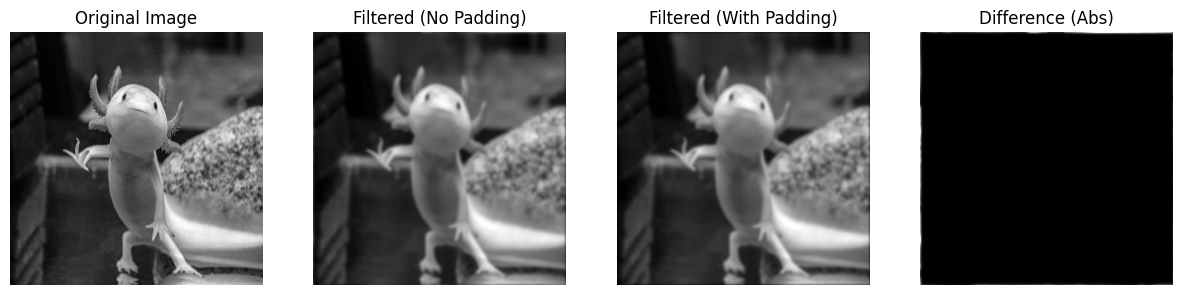

Max difference: 61
Mean difference: 0.421356201171875


In [5]:
# Display the results
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(sample_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(filtered_no_pad, cmap='gray')
plt.title('Filtered (No Padding)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(filtered_pad, cmap='gray')
plt.title('Filtered (With Padding)')
plt.axis('off')

# Difference
diff = np.abs(filtered_no_pad.astype(np.int16) - filtered_pad.astype(np.int16))
plt.subplot(1, 4, 4)
plt.imshow(diff, cmap='gray')
plt.title('Difference (Abs)')
plt.axis('off')

plt.show()

# Print some stats
print("Max difference:", np.max(diff))
print("Mean difference:", np.mean(diff))